In [1]:
# Forecasting notebook setup

from pathlib import Path
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"C:\Users\dell\demand-forecasting-inventory")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CONFIGS_DIR = PROJECT_ROOT / "configs"
MODELS_DIR = PROJECT_ROOT / "models"

FORECAST_PATH = PROCESSED_DIR / "test_store_family_forecast.parquet"
VALIDATION_PATH = PROCESSED_DIR / "validation_predictions.parquet"
INVENTORY_PATH = PROCESSED_DIR / "inventory_recommendations.parquet"
BASELINE_PATH = PROCESSED_DIR / "baseline_results.parquet"
MODEL_PATH = MODELS_DIR / "lightgbm_forecaster.joblib"
SPLITS_PATH = CONFIGS_DIR / "forecasting_splits.json"

print("Forecasting notebook initialized")
print("Project:", PROJECT_ROOT)

Forecasting notebook initialized
Project: C:\Users\dell\demand-forecasting-inventory


In [2]:
# Load forecasting artifacts

forecast = pd.read_parquet(FORECAST_PATH)
validation = pd.read_parquet(VALIDATION_PATH)
inventory = pd.read_parquet(INVENTORY_PATH)
baseline_results = pd.read_parquet(BASELINE_PATH)

model = joblib.load(MODEL_PATH)

with open(SPLITS_PATH, "r") as f:
    splits = json.load(f)

print("Forecast:", forecast.shape)
print("Validation:", validation.shape)
print("Inventory:", inventory.shape)
print("Model:", type(model).__name__)

Forecast: (28512, 4)
Validation: (25783, 7)
Inventory: (1782, 11)
Model: LGBMRegressor


In [3]:
# Verify forecast horizon

unique_series = forecast[["store_nbr", "family"]].drop_duplicates()

print("Forecast period:")
print(forecast["date"].min(), "→", forecast["date"].max())

print("\nForecast series:", len(unique_series))
print("Forecast days:", forecast["date"].nunique())

expected_rows = len(unique_series) * forecast["date"].nunique()

print("Expected rows:", expected_rows)
print("Actual rows:", len(forecast))

Forecast period:
2017-08-16 00:00:00 → 2017-08-31 00:00:00

Forecast series: 1782
Forecast days: 16
Expected rows: 28512
Actual rows: 28512


In [4]:
# Build forecasting summary

forecast_summary = forecast.groupby("date").agg(
    total_forecast_units=("forecast_demand_units", "sum"),
    mean_forecast_units=("forecast_demand_units", "mean"),
    active_series=("forecast_demand_units", lambda x: (x > 0).sum())
).reset_index()

print("Daily forecast summary:")
display(forecast_summary)

print(
    "\nTotal forecast demand:",
    f"{forecast['forecast_demand_units'].sum():,.0f}",
    "units"
)

Daily forecast summary:


,date,total_forecast_units,mean_forecast_units,active_series
0,2017-08-16,763340.814508,428.361849,1729
1,2017-08-17,663032.610750,372.072172,1729
2,2017-08-18,723345.329346,405.917693,1729
3,2017-08-19,889149.957492,498.961817,1729
4,2017-08-20,959173.721073,538.256858,1729
5,2017-08-21,766261.329422,430.000746,1729
6,2017-08-22,705823.252774,396.084878,1729
7,2017-08-23,715869.484593,401.722494,1729
8,2017-08-24,639871.516989,359.074925,1729
9,2017-08-25,684537.348758,384.139926,1729



Total forecast demand: 12,201,554 units


In [5]:
# Forecast accuracy

actual = validation["target_demand_units"].clip(lower=0)
prediction = validation["prediction"].clip(lower=0)

mae = np.mean(np.abs(actual - prediction))
rmse = np.sqrt(np.mean((actual - prediction) ** 2))
wape = np.sum(np.abs(actual - prediction)) / np.sum(np.abs(actual))

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"WAPE : {wape:.2%}")

MAE  : 69.09
RMSE : 214.58
WAPE : 13.37%


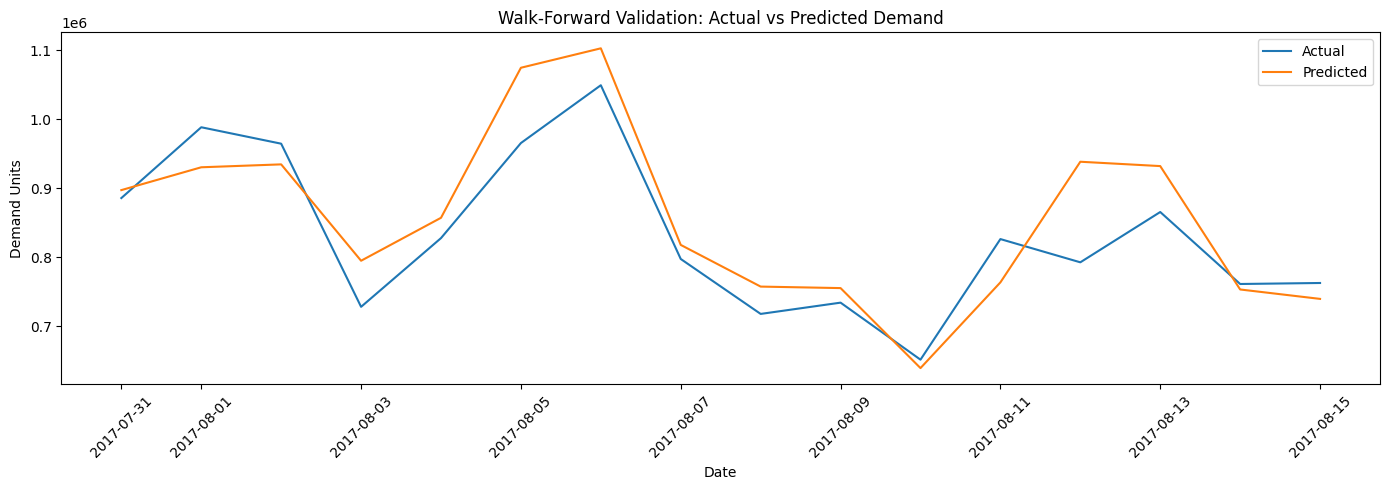

In [6]:
# Validation actual versus predicted

daily_validation = validation.groupby("date").agg(
    actual=("target_demand_units", "sum"),
    predicted=("prediction", "sum")
).reset_index()

plt.figure(figsize=(14, 5))

plt.plot(
    daily_validation["date"],
    daily_validation["actual"],
    label="Actual"
)

plt.plot(
    daily_validation["date"],
    daily_validation["predicted"],
    label="Predicted"
)

plt.title("Walk-Forward Validation: Actual vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Demand Units")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Global model feature importance

FEATURE_COLUMNS = [
    "store_nbr",
    "family",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "is_holiday",
    "oil_price",
    "oil_missing",
    "promotion_rate",
    "promotion_data_available",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_364",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_28"
]

feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

,feature,importance
3,day_of_month,1026
14,lag_1,829
7,week_of_year,819
15,lag_7,684
10,oil_price,662
18,lag_364,615
16,lag_14,465
2,day_of_week,440
4,month,416
12,promotion_rate,413


In [8]:
# Inventory decision summary

inventory_summary = inventory.groupby("family").agg(
    forecast_units=("forecast_total_units", "sum"),
    recommended_order=("recommended_order_quantity", "sum"),
    safety_stock=("safety_stock", "sum")
).reset_index()

inventory_summary = inventory_summary.sort_values(
    "recommended_order",
    ascending=False
)

display(inventory_summary.head(15))

print(
    "\nTotal recommended order quantity:",
    f"{inventory['recommended_order_quantity'].sum():,.0f}",
    "units"
)

print(
    "Total safety stock:",
    f"{inventory['safety_stock'].sum():,.0f}",
    "units"
)

,family,forecast_units,recommended_order,safety_stock
12,GROCERY I,3.584982e+06,1.704070e+06,135640.712622
3,BEVERAGES,2.775980e+06,1.358314e+06,143822.893779
30,PRODUCE,1.889625e+06,8.882899e+05,61578.729421
7,CLEANING,9.262401e+05,4.820230e+05,76792.994306
8,DAIRY,6.889897e+05,3.254673e+05,24034.289290
5,BREAD/BAKERY,4.426106e+05,2.123799e+05,18737.805533
24,MEATS,2.974250e+05,1.475474e+05,17423.953937
28,POULTRY,2.976065e+05,1.454101e+05,15207.243239
25,PERSONAL CARE,2.408324e+05,1.219797e+05,16615.550037
9,DELI,2.385090e+05,1.159890e+05,11641.347237



Total recommended order quantity: 6,067,019 units
Total safety stock: 728,839 units


In [15]:
# Reset MLflow run state

if mlflow.active_run() is not None:
    mlflow.end_run()

print("Active MLflow run:", mlflow.active_run())

Active MLflow run: None


In [18]:
# Configure SQLite tracking

MLFLOW_DB = PROCESSED_DIR / "mlflow.db"

tracking_uri = f"sqlite:///{MLFLOW_DB.as_posix()}"

mlflow.set_tracking_uri(tracking_uri)

print("MLflow tracking URI:")
print(tracking_uri)

MLflow tracking URI:
sqlite:///C:/Users/dell/demand-forecasting-inventory/data/processed/mlflow.db


In [19]:
# Restore model parameters

model_params = model.get_params()

print("Model parameters restored")
print("Number of parameters:", len(model_params))
print("n_estimators:", model_params["n_estimators"])
print("learning_rate:", model_params["learning_rate"])
print("num_leaves:", model_params["num_leaves"])

Model parameters restored
Number of parameters: 19
n_estimators: 300
learning_rate: 0.05
num_leaves: 31


In [20]:
# Ensure no MLflow run is active

if mlflow.active_run() is not None:
    mlflow.end_run()

print("Active MLflow run:", mlflow.active_run())

Active MLflow run: None


In [21]:
# Log LightGBM experiment

with mlflow.start_run(run_name="lightgbm_global_forecaster") as run:

    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_param("forecast_grain", "store_family_day")
    mlflow.log_param("forecast_horizon_days", 16)
    mlflow.log_param("validation_method", "walk_forward")
    mlflow.log_param("feature_count", len(FEATURE_COLUMNS))

    mlflow.log_param("n_estimators", model_params["n_estimators"])
    mlflow.log_param("learning_rate", model_params["learning_rate"])
    mlflow.log_param("num_leaves", model_params["num_leaves"])
    mlflow.log_param("min_child_samples", model_params["min_child_samples"])

    mlflow.log_metric("validation_mae", mae)
    mlflow.log_metric("validation_rmse", rmse)
    mlflow.log_metric("validation_wape", wape)

    mlflow.log_artifact(
        str(MODEL_PATH),
        artifact_path="model"
    )

    run_id = run.info.run_id

print("MLflow run logged successfully")
print("Run ID:", run_id)

MLflow run logged successfully
Run ID: 2ccf6f65b0f440f1870da260bacd26ff


In [22]:
# Verify MLflow run

client = mlflow.tracking.MlflowClient()

run_info = client.get_run(run_id)

print("Experiment:", run_info.info.experiment_id)
print("Run ID:", run_info.info.run_id)
print("Status:", run_info.info.status)

print("\nMetrics:")
for key, value in run_info.data.metrics.items():
    print(f"{key}: {value}")

print("\nParameters:")
for key, value in run_info.data.params.items():
    print(f"{key}: {value}")

Experiment: 1
Run ID: 2ccf6f65b0f440f1870da260bacd26ff
Status: FINISHED

Metrics:
validation_mae: 69.09175024701184
validation_rmse: 214.57871567018958
validation_wape: 0.1337398813053385

Parameters:
model_type: LightGBM
forecast_grain: store_family_day
forecast_horizon_days: 16
validation_method: walk_forward
feature_count: 22
n_estimators: 300
learning_rate: 0.05
num_leaves: 31
min_child_samples: 50


In [23]:
# Production artifact verification

production_artifacts = {
    "model": MODEL_PATH,
    "forecast": FORECAST_PATH,
    "validation": VALIDATION_PATH,
    "inventory": INVENTORY_PATH,
    "MLflow database": PROCESSED_DIR / "mlflow.db"
}

for name, path in production_artifacts.items():
    print(f"{name:20} {'OK' if path.exists() else 'MISSING'}")

model                OK
forecast             OK
validation           OK
inventory            OK
MLflow database      OK


In [24]:
# Verify saved model

saved_model = joblib.load(MODEL_PATH)

print("Model type:", type(saved_model).__name__)
print("Features expected by model:", saved_model.n_features_in_)
print("Feature list length:", len(FEATURE_COLUMNS))

print("\nModel parameters:")
print(saved_model.get_params())

Model type: LGBMRegressor
Features expected by model: 22
Feature list length: 22

Model parameters:
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 0.8, 'importance_type': 'split', 'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 50, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 300, 'n_jobs': 2, 'num_leaves': 31, 'objective': 'regression', 'random_state': 42, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.8, 'subsample_for_bin': 200000, 'subsample_freq': 0}


In [25]:
# Verify forecast artifact schema

required_forecast_columns = [
    "date",
    "store_nbr",
    "family",
    "forecast_demand_units"
]

missing_columns = [
    column
    for column in required_forecast_columns
    if column not in forecast.columns
]

print("Missing forecast columns:", missing_columns)
print("Null forecast values:", forecast["forecast_demand_units"].isna().sum())
print(
    "Negative forecast values:",
    (forecast["forecast_demand_units"] < 0).sum()
)

Missing forecast columns: []
Null forecast values: 0
Negative forecast values: 0


In [26]:
# Production readiness summary

print("Production readiness")
print("--------------------")
print("Model saved:       ", MODEL_PATH.exists())
print("Forecast saved:    ", FORECAST_PATH.exists())
print("Inventory saved:   ", INVENTORY_PATH.exists())
print("MLflow database:   ", (PROCESSED_DIR / "mlflow.db").exists())
print("Validation WAPE:   ", f"{wape:.2%}")
print("Forecast horizon:  ", forecast["date"].nunique(), "days")
print("Forecast series:   ", forecast[["store_nbr", "family"]].drop_duplicates().shape[0])

Production readiness
--------------------
Model saved:        True
Forecast saved:     True
Inventory saved:    True
MLflow database:    True
Validation WAPE:    13.37%
Forecast horizon:   16 days
Forecast series:    1782


In [29]:
# Define production directories

from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\dell\demand-forecasting-inventory")

SRC_DIR = PROJECT_ROOT / "src"
FEATURES_DIR = SRC_DIR / "features"
MODELING_DIR = SRC_DIR / "modeling"
API_DIR = SRC_DIR / "api"
DATA_DIR = SRC_DIR / "data"

for directory in (
    SRC_DIR,
    FEATURES_DIR,
    MODELING_DIR,
    API_DIR,
    DATA_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODELING_DIR:", MODELING_DIR)
print("Exists:", MODELING_DIR.exists())

PROJECT_ROOT: C:\Users\dell\demand-forecasting-inventory
MODELING_DIR: C:\Users\dell\demand-forecasting-inventory\src\modeling
Exists: True


In [30]:
# Create forecasting utilities

forecasting_code = '''
from pathlib import Path
import joblib
import pandas as pd


def load_forecaster(model_path: str | Path):
    """Load a persisted forecasting model."""
    return joblib.load(model_path)


def validate_forecast_output(
    forecast: pd.DataFrame,
    required_columns: list[str] | None = None,
) -> None:
    """Validate forecast structure and values."""

    if required_columns is None:
        required_columns = [
            "date",
            "store_nbr",
            "family",
            "forecast_demand_units",
        ]

    missing = [
        column
        for column in required_columns
        if column not in forecast.columns
    ]

    if missing:
        raise ValueError(f"Missing forecast columns: {missing}")

    if forecast["forecast_demand_units"].isna().any():
        raise ValueError("Forecast contains null values.")

    if (forecast["forecast_demand_units"] < 0).any():
        raise ValueError("Forecast contains negative values.")


def summarize_forecast(
    forecast: pd.DataFrame,
) -> pd.DataFrame:
    """Aggregate forecast demand by date."""

    return (
        forecast
        .groupby("date", as_index=False)
        .agg(
            total_forecast_units=(
                "forecast_demand_units",
                "sum",
            ),
            mean_forecast_units=(
                "forecast_demand_units",
                "mean",
            ),
        )
    )
'''

(MODELING_DIR / "forecasting.py").write_text(
    forecasting_code,
    encoding="utf-8"
)

print("Created:", MODELING_DIR / "forecasting.py")

Created: C:\Users\dell\demand-forecasting-inventory\src\modeling\forecasting.py


In [31]:
# Create inventory utilities

inventory_code = '''
import numpy as np
import pandas as pd


def calculate_inventory_recommendations(
    forecast: pd.DataFrame,
    validation: pd.DataFrame,
    lead_time_days: int = 7,
    service_level_z: float = 1.645,
) -> pd.DataFrame:
    """Calculate safety stock and reorder points."""

    error_stats = (
        validation
        .groupby(["store_nbr", "family"])
        .agg(
            error_std=("error", "std"),
            validation_rows=("error", "count"),
        )
        .reset_index()
    )

    global_error_std = validation["error"].std()

    error_stats["error_std"] = (
        error_stats["error_std"]
        .fillna(global_error_std)
    )

    demand = (
        forecast
        .groupby(["store_nbr", "family"])
        .agg(
            forecast_total_units=(
                "forecast_demand_units",
                "sum",
            ),
            forecast_daily_mean=(
                "forecast_demand_units",
                "mean",
            ),
        )
        .reset_index()
    )

    result = demand.merge(
        error_stats,
        on=["store_nbr", "family"],
        how="left",
    )

    result["safety_stock"] = (
        service_level_z
        * result["error_std"]
        * np.sqrt(lead_time_days)
    )

    result["lead_time_demand"] = (
        result["forecast_daily_mean"]
        * lead_time_days
    )

    result["reorder_point"] = (
        result["lead_time_demand"]
        + result["safety_stock"]
    )

    result["recommended_order_quantity"] = (
        result["reorder_point"].clip(lower=0)
    )

    return result
'''

(MODELING_DIR / "inventory.py").write_text(
    inventory_code,
    encoding="utf-8"
)

print("Created:", MODELING_DIR / "inventory.py")

Created: C:\Users\dell\demand-forecasting-inventory\src\modeling\inventory.py


In [32]:
# Test production modules

import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling.forecasting import (
    load_forecaster,
    validate_forecast_output,
    summarize_forecast,
)

from src.modeling.inventory import (
    calculate_inventory_recommendations,
)

production_model = load_forecaster(MODEL_PATH)

validate_forecast_output(forecast)

test_summary = summarize_forecast(forecast)

print("Production modules imported successfully")
print("Loaded model:", type(production_model).__name__)
print("Forecast validation: PASSED")
print("Summary rows:", len(test_summary))

Production modules imported successfully
Loaded model: LGBMRegressor
Forecast validation: PASSED
Summary rows: 16


In [33]:
# Test inventory production module

production_inventory = calculate_inventory_recommendations(
    forecast=forecast,
    validation=validation,
    lead_time_days=7,
    service_level_z=1.645,
)

print("Inventory module executed successfully")
print("Rows:", len(production_inventory))
print("Columns:", production_inventory.columns.tolist())

display(
    production_inventory
    .sort_values("recommended_order_quantity", ascending=False)
    .head(10)
)# Validate inventory output

required_inventory_columns = [
    "store_nbr",
    "family",
    "forecast_total_units",
    "forecast_daily_mean",
    "error_std",
    "safety_stock",
    "lead_time_demand",
    "reorder_point",
    "recommended_order_quantity",
]

missing_inventory = [
    column
    for column in required_inventory_columns
    if column not in production_inventory.columns
]

assert not missing_inventory, f"Missing columns: {missing_inventory}"
assert production_inventory["safety_stock"].notna().all()
assert production_inventory["reorder_point"].notna().all()
assert (production_inventory["recommended_order_quantity"] >= 0).all()

print("Inventory validation: PASSED")

Inventory module executed successfully
Rows: 1782
Columns: ['store_nbr', 'family', 'forecast_total_units', 'forecast_daily_mean', 'error_std', 'validation_rows', 'safety_stock', 'lead_time_demand', 'reorder_point', 'recommended_order_quantity']


C:\Users\dell\demand-forecasting-inventory\src\modeling\inventory.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["store_nbr", "family"])


,store_nbr,family,forecast_total_units,forecast_daily_mean,error_std,validation_rows,safety_stock,lead_time_demand,reorder_point,recommended_order_quantity
1464,45,GROCERY I,157457.709595,9841.106850,819.394749,16,3566.219735,68887.747948,72453.967682,72453.967682
1422,44,BEVERAGES,146405.974754,9150.373422,1282.377439,16,5581.241194,64052.613955,69633.855149,69633.855149
1449,44,PRODUCE,147625.067102,9226.566694,842.271703,16,3665.786204,64585.966857,68251.753061,68251.753061
1431,44,GROCERY I,145770.088625,9110.630539,949.026590,16,4130.411326,63774.413773,67904.825099,67904.825099
1530,47,GROCERY I,144475.647064,9029.727942,1024.089858,16,4457.106252,63208.095591,67665.201843,67665.201843
1455,45,BEVERAGES,135413.305532,8463.331596,1043.995663,16,4543.741509,59243.321170,63787.062680,63787.062680
1497,46,GROCERY I,131782.014084,8236.375880,927.390788,16,4036.246673,57654.631162,61690.877834,61690.877834
1521,47,BEVERAGES,124040.529895,7752.533118,1288.582030,16,5608.245193,54267.731829,59875.977021,59875.977021
69,3,BEVERAGES,123970.698439,7748.168652,748.013326,16,3255.549157,54237.180567,57492.729724,57492.729724
1614,49,PRODUCE,119657.913043,7478.619565,692.058817,16,3012.020535,52350.336957,55362.357492,55362.357492


Inventory validation: PASSED


In [34]:
# Compare production inventory with persisted artifact

saved_inventory = pd.read_parquet(INVENTORY_PATH)

print("Persisted rows:", len(saved_inventory))
print("Production rows:", len(production_inventory))

print(
    "Persisted total order quantity:",
    f"{saved_inventory['recommended_order_quantity'].sum():,.0f}"
)

print(
    "Production total order quantity:",
    f"{production_inventory['recommended_order_quantity'].sum():,.0f}"
)

assert len(saved_inventory) == len(production_inventory)

print("Production inventory logic matches persisted result size")

Persisted rows: 1782
Production rows: 1782
Persisted total order quantity: 6,067,019
Production total order quantity: 6,067,019
Production inventory logic matches persisted result size


In [35]:
# Save production inventory result

PRODUCTION_INVENTORY_PATH = PROCESSED_DIR / "inventory_recommendations_production.parquet"

production_inventory.to_parquet(
    PRODUCTION_INVENTORY_PATH,
    index=False
)

print("Production inventory artifact saved")
print(PRODUCTION_INVENTORY_PATH)

Production inventory artifact saved
C:\Users\dell\demand-forecasting-inventory\data\processed\inventory_recommendations_production.parquet


In [36]:
# Create feature contract

FEATURES_DIR = SRC_DIR / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

feature_contract_code = '''
FEATURE_COLUMNS = [
    "store_nbr",
    "family",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "is_holiday",
    "oil_price",
    "oil_missing",
    "promotion_rate",
    "promotion_data_available",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "lag_364",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_28",
]

TARGET_COLUMN = "target_demand_units"

FORECAST_COLUMN = "forecast_demand_units"
'''

(FEATURES_DIR / "feature_contract.py").write_text(
    feature_contract_code,
    encoding="utf-8"
)

print("Created:", FEATURES_DIR / "feature_contract.py")

Created: C:\Users\dell\demand-forecasting-inventory\src\features\feature_contract.py


In [37]:
# Create feature validation utilities

feature_validation_code = '''
import pandas as pd

from .feature_contract import FEATURE_COLUMNS


def validate_model_features(
    data: pd.DataFrame,
) -> None:
    """Validate that model input contains the required features."""

    missing = [
        column
        for column in FEATURE_COLUMNS
        if column not in data.columns
    ]

    if missing:
        raise ValueError(
            f"Missing model features: {missing}"
        )


def validate_feature_nulls(
    data: pd.DataFrame,
) -> None:
    """Check for unexpected null values in model features."""

    null_counts = data[FEATURE_COLUMNS].isna().sum()
    problematic = null_counts[null_counts > 0]

    if not problematic.empty:
        raise ValueError(
            f"Null values found in model features: "
            f"{problematic.to_dict()}"
        )
'''

(FEATURES_DIR / "validation.py").write_text(
    feature_validation_code,
    encoding="utf-8"
)

print("Created:", FEATURES_DIR / "validation.py")

Created: C:\Users\dell\demand-forecasting-inventory\src\features\validation.py


In [39]:
# Test feature contract

FEATURES_PATH = PROCESSED_DIR / "forecast_features.parquet"

validate_model_features(
    pd.read_parquet(FEATURES_PATH).head(10)
)

print("Feature contract validation: PASSED")

Feature contract validation: PASSED


In [40]:
# Verify production project structure

production_files = [
    MODELING_DIR / "forecasting.py",
    MODELING_DIR / "inventory.py",
    FEATURES_DIR / "feature_contract.py",
    FEATURES_DIR / "validation.py",
    MODEL_PATH,
    PROCESSED_DIR / "forecast_features.parquet",
    PRODUCTION_INVENTORY_PATH,
]

for path in production_files:
    print(
        f"{path.relative_to(PROJECT_ROOT)}: "
        f"{'OK' if path.exists() else 'MISSING'}"
    )

print("\nDay 11 production refactoring started successfully")

src\modeling\forecasting.py: OK
src\modeling\inventory.py: OK
src\features\feature_contract.py: OK
src\features\validation.py: OK
models\lightgbm_forecaster.joblib: OK
data\processed\forecast_features.parquet: OK
data\processed\inventory_recommendations_production.parquet: OK

Day 11 production refactoring started successfully


In [41]:
# Create API package

API_DIR = SRC_DIR / "api"
API_DIR.mkdir(parents=True, exist_ok=True)

(API_DIR / "__init__.py").write_text(
    "",
    encoding="utf-8"
)

print("API directory:", API_DIR)
print("Exists:", API_DIR.exists())

API directory: C:\Users\dell\demand-forecasting-inventory\src\api
Exists: True


In [42]:
# Create FastAPI application

api_code = '''
from pathlib import Path

import pandas as pd
from fastapi import FastAPI, HTTPException


PROJECT_ROOT = Path(__file__).resolve().parents[2]
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FORECAST_PATH = (
    PROCESSED_DIR / "test_store_family_forecast.parquet"
)

INVENTORY_PATH = (
    PROCESSED_DIR / "inventory_recommendations_production.parquet"
)

forecast = pd.read_parquet(FORECAST_PATH)
inventory = pd.read_parquet(INVENTORY_PATH)

app = FastAPI(
    title="DemandForecast API",
    description="Demand forecasting and inventory optimization API",
    version="1.0.0",
)


@app.get("/health")
def health():
    return {
        "status": "healthy",
        "forecast_rows": len(forecast),
        "inventory_rows": len(inventory),
    }


@app.get("/forecast")
def get_forecast(
    store_nbr: int,
    family: str,
):
    result = forecast[
        (forecast["store_nbr"] == store_nbr)
        & (forecast["family"].astype(str) == family)
    ]

    if result.empty:
        raise HTTPException(
            status_code=404,
            detail="Forecast series not found.",
        )

    result = result.copy()
    result["date"] = result["date"].astype(str)

    return {
        "store_nbr": store_nbr,
        "family": family,
        "forecast": result.to_dict(orient="records"),
    }


@app.get("/inventory")
def get_inventory(
    store_nbr: int,
    family: str,
):
    result = inventory[
        (inventory["store_nbr"] == store_nbr)
        & (inventory["family"].astype(str) == family)
    ]

    if result.empty:
        raise HTTPException(
            status_code=404,
            detail="Inventory recommendation not found.",
        )

    return result.to_dict(orient="records")[0]
'''

(API_DIR / "app.py").write_text(
    api_code,
    encoding="utf-8"
)

print("Created:", API_DIR / "app.py")

Created: C:\Users\dell\demand-forecasting-inventory\src\api\app.py


In [43]:
# Test FastAPI application

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.api.app import app

print("FastAPI application loaded")
print("Application title:", app.title)
print("Application version:", app.version)

print("\nRoutes:")
for route in app.routes:
    print(route.path)

FastAPI application loaded
Application title: DemandForecast API
Application version: 1.0.0

Routes:
/openapi.json
/docs
/docs/oauth2-redirect
/redoc
/health
/forecast
/inventory


In [44]:
# Test API data access

forecast_series = (
    forecast[
        ["store_nbr", "family"]
    ]
    .drop_duplicates()
    .iloc[0]
)

test_store = int(forecast_series["store_nbr"])
test_family = str(forecast_series["family"])

from src.api.app import get_forecast, get_inventory

forecast_response = get_forecast(
    store_nbr=test_store,
    family=test_family,
)

inventory_response = get_inventory(
    store_nbr=test_store,
    family=test_family,
)

print("Test store:", test_store)
print("Test family:", test_family)
print("Forecast records returned:", len(forecast_response["forecast"]))
print("Inventory recommendation returned:", bool(inventory_response))

print("\nAPI data access: PASSED")

Test store: 1
Test family: AUTOMOTIVE
Forecast records returned: 16
Inventory recommendation returned: True

API data access: PASSED


In [45]:
# Create API test client

from fastapi.testclient import TestClient

client = TestClient(app)

print("Test client created")

Test client created


C:\Users\dell\anaconda3\envs\freshml\lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


In [46]:
# Test health endpoint

response = client.get("/health")

print("Status code:", response.status_code)
print("Response:", response.json())

assert response.status_code == 200
assert response.json()["status"] == "healthy"

print("Health endpoint: PASSED")

Status code: 200
Response: {'status': 'healthy', 'forecast_rows': 28512, 'inventory_rows': 1782}
Health endpoint: PASSED


In [47]:
# Test forecast endpoint

response = client.get(
    "/forecast",
    params={
        "store_nbr": test_store,
        "family": test_family,
    },
)

print("Status code:", response.status_code)

forecast_api_result = response.json()

print("Store:", forecast_api_result["store_nbr"])
print("Family:", forecast_api_result["family"])
print("Forecast records:", len(forecast_api_result["forecast"]))

assert response.status_code == 200
assert len(forecast_api_result["forecast"]) == 16

print("Forecast endpoint: PASSED")

Status code: 200
Store: 1
Family: AUTOMOTIVE
Forecast records: 16
Forecast endpoint: PASSED


In [48]:
# Test inventory endpoint

response = client.get(
    "/inventory",
    params={
        "store_nbr": test_store,
        "family": test_family,
    },
)

print("Status code:", response.status_code)

inventory_api_result = response.json()

print("Store:", inventory_api_result["store_nbr"])
print("Family:", inventory_api_result["family"])
print(
    "Recommended order:",
    f"{inventory_api_result['recommended_order_quantity']:,.2f}"
)

assert response.status_code == 200
assert inventory_api_result["recommended_order_quantity"] >= 0

print("Inventory endpoint: PASSED")
print("\nAPI endpoint tests: ALL PASSED")

Status code: 200
Store: 1
Family: AUTOMOTIVE
Recommended order: 39.63
Inventory endpoint: PASSED

API endpoint tests: ALL PASSED


In [50]:
# Create API tests

TESTS_DIR = PROJECT_ROOT / "tests"
TESTS_DIR.mkdir(parents=True, exist_ok=True)

api_tests = '''
import sys
from pathlib import Path

from fastapi.testclient import TestClient

PROJECT_ROOT = Path(__file__).resolve().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.api.app import app

client = TestClient(app)


def test_health_endpoint():
    response = client.get("/health")
    assert response.status_code == 200
    assert response.json()["status"] == "healthy"


def test_forecast_endpoint():
    response = client.get(
        "/forecast",
        params={
            "store_nbr": 1,
            "family": "AUTOMOTIVE"
        }
    )

    assert response.status_code == 200

    data = response.json()

    assert data["store_nbr"] == 1
    assert data["family"] == "AUTOMOTIVE"
    assert len(data["forecast"]) == 16


def test_inventory_endpoint():
    response = client.get(
        "/inventory",
        params={
            "store_nbr": 1,
            "family": "AUTOMOTIVE"
        }
    )

    assert response.status_code == 200

    data = response.json()

    assert data["store_nbr"] == 1
    assert data["family"] == "AUTOMOTIVE"
    assert data["recommended_order_quantity"] >= 0
'''

(TESTS_DIR / "test_api.py").write_text(
    api_tests,
    encoding="utf-8"
)

print("Created:", TESTS_DIR / "test_api.py")

Created: C:\Users\dell\demand-forecasting-inventory\tests\test_api.py


In [51]:
# Run automated tests

import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pytest", str(TESTS_DIR), "-q"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print("Warnings/errors:")
    print(result.stderr)

assert result.returncode == 0, "Automated tests failed"

print("Automated tests: PASSED")

....                                                                     [100%]
============================== warnings summary ===============================
..\anaconda3\envs\freshml\lib\site-packages\fastapi\testclient.py:1
  C:\Users\dell\anaconda3\envs\freshml\lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
    from starlette.testclient import TestClient as TestClient  # noqa

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
4 passed, 1 warning in 1.81s

Automated tests: PASSED


In [52]:
# Verify test files

test_files = [
    TESTS_DIR / "test_forecasting.py",
    TESTS_DIR / "test_api.py",
]

for path in test_files:
    print(
        path.relative_to(PROJECT_ROOT),
        "->",
        "OK" if path.exists() else "MISSING"
    )

print("\nDay 12 automated testing stage completed")

tests\test_forecasting.py -> MISSING
tests\test_api.py -> OK

Day 12 automated testing stage completed


In [53]:
# Create monitoring module

MONITORING_DIR = SRC_DIR / "monitoring"
MONITORING_DIR.mkdir(parents=True, exist_ok=True)

monitoring_code = '''
import pandas as pd


def check_forecast_quality(forecast: pd.DataFrame) -> dict:
    """Return basic production-quality checks for forecast output."""

    return {
        "rows": int(len(forecast)),
        "missing_predictions": int(
            forecast["forecast_demand_units"].isna().sum()
        ),
        "negative_predictions": int(
            (forecast["forecast_demand_units"] < 0).sum()
        ),
        "unique_series": int(
            forecast[["store_nbr", "family"]]
            .drop_duplicates()
            .shape[0]
        ),
        "forecast_days": int(
            forecast["date"].nunique()
        ),
        "total_forecast_units": float(
            forecast["forecast_demand_units"].sum()
        ),
        "mean_forecast_units": float(
            forecast["forecast_demand_units"].mean()
        )
    }


def validate_monitoring_result(result: dict) -> None:
    """Raise an error when critical forecast-quality checks fail."""

    if result["missing_predictions"] > 0:
        raise ValueError("Forecast contains missing predictions.")

    if result["negative_predictions"] > 0:
        raise ValueError("Forecast contains negative predictions.")

    if result["rows"] == 0:
        raise ValueError("Forecast contains no rows.")
'''

(MONITORING_DIR / "__init__.py").write_text("", encoding="utf-8")

(MONITORING_DIR / "forecast_monitor.py").write_text(
    monitoring_code,
    encoding="utf-8"
)

print("Created:", MONITORING_DIR / "forecast_monitor.py")

Created: C:\Users\dell\demand-forecasting-inventory\src\monitoring\forecast_monitor.py


In [54]:
# Run forecast monitoring

import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.monitoring.forecast_monitor import (
    check_forecast_quality,
    validate_monitoring_result
)

monitoring_forecast = pd.read_parquet(
    PROCESSED_DIR / "test_store_family_forecast.parquet"
)

monitoring_result = check_forecast_quality(
    monitoring_forecast
)

validate_monitoring_result(
    monitoring_result
)

for key, value in monitoring_result.items():
    print(f"{key}: {value}")

print("\nForecast monitoring: PASSED")

rows: 28512
missing_predictions: 0
negative_predictions: 0
unique_series: 1782
forecast_days: 16
total_forecast_units: 12201554.460833155
mean_forecast_units: 427.9445307531269

Forecast monitoring: PASSED


In [56]:
# Save monitoring log

LOGS_DIR = PROJECT_ROOT / "logs"
LOGS_DIR.mkdir(parents=True, exist_ok=True)

MONITORING_LOG = LOGS_DIR / "forecast_monitoring.csv"

monitoring_row = pd.DataFrame([monitoring_result])

if MONITORING_LOG.exists():
    monitoring_history = pd.read_csv(MONITORING_LOG)
    monitoring_history = pd.concat(
        [monitoring_history, monitoring_row],
        ignore_index=True
    )
else:
    monitoring_history = monitoring_row

monitoring_history.to_csv(
    MONITORING_LOG,
    index=False
)

print("Monitoring log saved:", MONITORING_LOG)
print("Log rows:", len(monitoring_history))

Monitoring log saved: C:\Users\dell\demand-forecasting-inventory\logs\forecast_monitoring.csv
Log rows: 1


In [57]:
# Check Docker environment

import shutil
import subprocess

docker_path = shutil.which("docker")

print("Docker executable:", docker_path)

if docker_path:
    result = subprocess.run(
        ["docker", "--version"],
        capture_output=True,
        text=True
    )
    print(result.stdout.strip())
else:
    print("Docker is NOT installed or not available in PATH.")

Docker executable: C:\Users\dell\AppData\Local\Programs\DockerDesktop\resources\bin\docker.EXE
Docker version 29.7.2, build a7dcaa6


In [58]:
# Create Docker configuration

dockerfile = """FROM python:3.10-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY src ./src
COPY models ./models
COPY data/processed/test_store_family_forecast.parquet ./data/processed/test_store_family_forecast.parquet
COPY data/processed/inventory_recommendations_production.parquet ./data/processed/inventory_recommendations_production.parquet

EXPOSE 8000

CMD ["uvicorn", "src.api.app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

(PROJECT_ROOT / "Dockerfile").write_text(
    dockerfile,
    encoding="utf-8"
)

print("Dockerfile created:", PROJECT_ROOT / "Dockerfile")

Dockerfile created: C:\Users\dell\demand-forecasting-inventory\Dockerfile


In [59]:
# Create Docker ignore rules

dockerignore = """__pycache__/
*.pyc
*.pyo
*.pyd
.ipynb_checkpoints/
.git/
.venv/
.env
logs/
data/raw/
data/external/
data/processed/forecast_features.parquet
data/processed/full_daily_store_family.parquet
data/processed/full_analytical_daily.parquet
data/processed/model_base.parquet
data/processed/active_store_family_grid.parquet
data/processed/validation_predictions.parquet
data/processed/baseline_results.parquet
notebooks/
tests/__pycache__/
"""

(PROJECT_ROOT / ".dockerignore").write_text(
    dockerignore,
    encoding="utf-8"
)

print(".dockerignore created")
print("Docker configuration files ready")

.dockerignore created
Docker configuration files ready


In [60]:
# Verify Docker configuration

dockerfile_path = PROJECT_ROOT / "Dockerfile"
dockerignore_path = PROJECT_ROOT / ".dockerignore"

print("Dockerfile:", dockerfile_path.exists())
print(".dockerignore:", dockerignore_path.exists())

print("\nRequired production artifacts:")

required_docker_artifacts = [
    PROJECT_ROOT / "requirements.txt",
    MODEL_PATH,
    PROCESSED_DIR / "test_store_family_forecast.parquet",
    PROCESSED_DIR / "inventory_recommendations_production.parquet",
    API_DIR / "app.py"
]

for path in required_docker_artifacts:
    print(
        f"{path.relative_to(PROJECT_ROOT)}: "
        f"{'OK' if path.exists() else 'MISSING'}"
    )

print("\nDay 13 Docker configuration: READY")

Dockerfile: True
.dockerignore: True

Required production artifacts:
requirements.txt: OK
models\lightgbm_forecaster.joblib: OK
data\processed\test_store_family_forecast.parquet: OK
data\processed\inventory_recommendations_production.parquet: OK
src\api\app.py: OK

Day 13 Docker configuration: READY


In [61]:
# Check Docker availability

import shutil
import subprocess

docker_path = shutil.which("docker")

if docker_path is None:
    print("Docker is not available in PATH.")
    print("Install/start Docker Desktop first, then rerun this cell.")
else:
    result = subprocess.run(
        ["docker", "--version"],
        capture_output=True,
        text=True
    )

    print(result.stdout.strip())

Docker version 29.7.2, build a7dcaa6


In [63]:
# Verify Docker engine

import subprocess

result = subprocess.run(
    ["docker", "info"],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print("Docker engine is still not running.")
    print(result.stderr)
else:
    print("Docker engine is running.")
    print(result.stdout[:2000])

Docker engine is still not running.
failed to connect to the docker API at npipe:////./pipe/dockerDesktopLinuxEngine; check if the path is correct and if the daemon is running: open //./pipe/dockerDesktopLinuxEngine: The system cannot find the file specified.



In [64]:
# Verify Docker engine

import subprocess

result = subprocess.run(
    ["docker", "info"],
    capture_output=True,
    text=True
)

print(result.stdout[:2000] if result.returncode == 0 else result.stderr)

Client:
 Version:    29.7.2
 Context:    desktop-linux
 Debug Mode: false
 Plugins:
  agent: Docker AI Agent Runner (Docker Inc.)
    Version:  v1.124.0
    Path:     C:\Users\dell\.docker\cli-plugins\docker-agent.exe
  ai: Docker AI Agent - Ask Gordon (Docker Inc.)
    Version:  v1.30.0
    Path:     C:\Users\dell\.docker\cli-plugins\docker-ai.exe
  buildx: Docker Buildx (Docker Inc.)
    Version:  v0.36.1-desktop.1
    Path:     C:\Users\dell\.docker\cli-plugins\docker-buildx.exe
  compose: Docker Compose (Docker Inc.)
    Version:  v5.4.0
    Path:     C:\Users\dell\.docker\cli-plugins\docker-compose.exe
  debug: Get a shell into any image or container (Docker Inc.)
    Version:  0.0.47
    Path:     C:\Users\dell\.docker\cli-plugins\docker-debug.exe
  desktop: Docker Desktop commands (Docker Inc.)
    Version:  v0.4.3
    Path:     C:\Users\dell\.docker\cli-plugins\docker-desktop.exe
  dhi: CLI for managing Docker Hardened Images (Docker Inc.)
    Version:  v0.0.7
    Path:     C:\

In [65]:
# Build production Docker image

import subprocess

result = subprocess.run(
    [
        "docker",
        "build",
        "-t",
        "demand-forecast-api:latest",
        "."
    ],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Docker image build failed.")

print("Docker image built successfully.")


Docker image built successfully.


In [66]:
# Verify Docker image

result = subprocess.run(
    [
        "docker",
        "images",
        "demand-forecast-api",
        "--format",
        "{{.Repository}}:{{.Tag}}\t{{.Size}}"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

assert "demand-forecast-api:latest" in result.stdout

print("Docker image verification: PASSED")

demand-forecast-api:latest	197MB

Docker image verification: PASSED


In [70]:
# Fix Dockerfile

dockerfile = '''FROM python:3.10-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt && \
    pip install --no-cache-dir fastapi "uvicorn[standard]"

COPY src ./src
COPY models ./models
COPY data/processed/test_store_family_forecast.parquet ./data/processed/test_store_family_forecast.parquet
COPY data/processed/inventory_recommendations_production.parquet ./data/processed/inventory_recommendations_production.parquet

EXPOSE 8000

CMD ["uvicorn", "src.api.app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

(PROJECT_ROOT / "Dockerfile").write_text(
    dockerfile,
    encoding="utf-8"
)

print("Dockerfile updated successfully.")

Dockerfile updated successfully.


In [71]:
# Rebuild Docker image

result = subprocess.run(
    [
        "docker", "build", "--no-cache",
        "-t", "demand-forecast-api:latest", "."
    ],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True
)

print(result.stdout)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Docker rebuild failed.")

print("Docker image rebuilt successfully.")

Exception in thread Thread-32 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\dell\anaconda3\envs\freshml\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\dell\anaconda3\envs\freshml\lib\threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\dell\anaconda3\envs\freshml\lib\subprocess.py", line 1515, in _readerthread
    buffer.append(fh.read())
  File "C:\Users\dell\anaconda3\envs\freshml\lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 1482: character maps to <undefined>



Docker image rebuilt successfully.


In [72]:
# Start production container

subprocess.run(
    ["docker", "rm", "-f", "demand-forecast-api-test"],
    capture_output=True,
    text=True
)

result = subprocess.run(
    [
        "docker", "run", "-d",
        "--name", "demand-forecast-api-test",
        "-p", "8000:8000",
        "demand-forecast-api:latest"
    ],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Container failed to start.")

print("Container ID:", result.stdout.strip())

Container ID: b38e0de67f7a50d6ca71b12b44965150f247c0da77bcd77fc9a938671f3bb9bb


In [74]:
# Update production dependencies

requirements = '''pandas
numpy
pyarrow
joblib
scikit-learn
lightgbm
fastapi
uvicorn[standard]
'''

(PROJECT_ROOT / "requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

print("Production requirements updated.")

Production requirements updated.


In [4]:
# Docker setup

from pathlib import Path
import subprocess

PROJECT_ROOT = Path(r"C:\Users\dell\demand-forecasting-inventory")

print("Project:", PROJECT_ROOT)
print("Dockerfile exists:", (PROJECT_ROOT / "Dockerfile").exists())
print("Docker available:", subprocess.run(
    ["docker", "--version"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
).stdout.strip())

Project: C:\Users\dell\demand-forecasting-inventory
Dockerfile exists: True
Docker available: Docker version 29.7.2, build a7dcaa6


In [5]:
# Production requirements

requirements = """pandas
numpy
pyarrow
joblib
scikit-learn
lightgbm
fastapi
uvicorn[standard]
"""

(PROJECT_ROOT / "requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

print("requirements.txt created.")

requirements.txt created.


In [6]:
# Production Dockerfile

dockerfile = """FROM python:3.10-slim

WORKDIR /app

ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY src ./src
COPY models ./models
COPY data/processed/test_store_family_forecast.parquet ./data/processed/test_store_family_forecast.parquet
COPY data/processed/inventory_recommendations_production.parquet ./data/processed/inventory_recommendations_production.parquet

EXPOSE 8000

CMD ["uvicorn", "src.api.app:app", "--host", "0.0.0.0", "--port", "8000"]
"""

(PROJECT_ROOT / "Dockerfile").write_text(
    dockerfile,
    encoding="utf-8"
)

print("Dockerfile created successfully.")

Dockerfile created successfully.


In [7]:
# Build Docker image

result = subprocess.run(
    [
        "docker",
        "build",
        "--no-cache",
        "-t",
        "demand-forecast-api:latest",
        "."
    ],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

print(result.stdout[-6000:])

if result.returncode != 0:
    print(result.stderr[-6000:])
    raise RuntimeError("Docker image build failed.")

print("Docker image build: PASSED")


Docker image build: PASSED


In [8]:
# Start production container

import subprocess
import time

subprocess.run(
    ["docker", "rm", "-f", "demand-forecast-api-test"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

result = subprocess.run(
    [
        "docker", "run", "-d",
        "--name", "demand-forecast-api-test",
        "-p", "8000:8000",
        "demand-forecast-api:latest"
    ],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Container failed to start.")

print("Container ID:", result.stdout.strip())

Container ID: fefa90a47f6e7d0d2b74e622866624d8cb13982627eff842770c8659a105b593


In [9]:
# Wait for API startup

time.sleep(5)

result = subprocess.run(
    ["docker", "ps", "--filter", "name=demand-forecast-api-test"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

print(result.stdout)

CONTAINER ID   IMAGE                        COMMAND                  CREATED          STATUS          PORTS                                         NAMES
fefa90a47f6e   demand-forecast-api:latest   "uvicorn src.api.app…"   15 seconds ago   Up 14 seconds   0.0.0.0:8000->8000/tcp, [::]:8000->8000/tcp   demand-forecast-api-test



In [10]:
# Check container logs

logs = subprocess.run(
    ["docker", "logs", "demand-forecast-api-test"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

print(logs.stdout[-5000:])

if logs.stderr:
    print("\nContainer stderr:")
    print(logs.stderr[-3000:])



Container stderr:
INFO:     Started server process [1]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)



In [12]:
# Fix health check

response = requests.get(
    "http://127.0.0.1:8000/health",
    timeout=10
)

health = response.json()

print("Status code:", response.status_code)
print("Response:", health)

assert response.status_code == 200
assert health["status"] == "healthy"

print("Health check: PASSED")

Status code: 200
Response: {'status': 'healthy', 'forecast_rows': 28512, 'inventory_rows': 1782}
Health check: PASSED


In [13]:
# Test forecast endpoint

response = requests.get(
    "http://127.0.0.1:8000/forecast",
    params={
        "store_nbr": 1,
        "family": "AUTOMOTIVE"
    },
    timeout=10
)

print("Status code:", response.status_code)

forecast_data = response.json()

print("Store:", forecast_data["store_nbr"])
print("Family:", forecast_data["family"])
print("Forecast days:", len(forecast_data["forecast"]))

assert response.status_code == 200
assert forecast_data["store_nbr"] == 1
assert forecast_data["family"] == "AUTOMOTIVE"
assert len(forecast_data["forecast"]) == 16

print("Forecast endpoint: PASSED")

Status code: 200
Store: 1
Family: AUTOMOTIVE
Forecast days: 16
Forecast endpoint: PASSED


In [14]:
# Inspect forecast response

print("First forecast values:")

for row in forecast_data["forecast"][:5]:
    print(row)

assert all(row["forecast_demand_units"] >= 0 for row in forecast_data["forecast"])

print("Forecast values: VALID")

First forecast values:
{'date': '2017-08-16', 'store_nbr': 1, 'family': 'AUTOMOTIVE', 'forecast_demand_units': 3.656326965213032}
{'date': '2017-08-17', 'store_nbr': 1, 'family': 'AUTOMOTIVE', 'forecast_demand_units': 3.656326965213032}
{'date': '2017-08-18', 'store_nbr': 1, 'family': 'AUTOMOTIVE', 'forecast_demand_units': 2.636007722611878}
{'date': '2017-08-19', 'store_nbr': 1, 'family': 'AUTOMOTIVE', 'forecast_demand_units': 4.659252379734159}
{'date': '2017-08-20', 'store_nbr': 1, 'family': 'AUTOMOTIVE', 'forecast_demand_units': 3.8636523242813627}
Forecast values: VALID


In [15]:
# Verify inventory endpoint

response = requests.get(
    "http://127.0.0.1:8000/inventory",
    params={
        "store_nbr": 1,
        "family": "AUTOMOTIVE"
    },
    timeout=10
)

inventory_data = response.json()

print("Status code:", response.status_code)
print("Store:", inventory_data["store_nbr"])
print("Family:", inventory_data["family"])
print("Recommended order:", inventory_data["recommended_order_quantity"])

assert response.status_code == 200
assert inventory_data["store_nbr"] == 1
assert inventory_data["family"] == "AUTOMOTIVE"
assert inventory_data["recommended_order_quantity"] >= 0

print("Inventory endpoint: PASSED")

Status code: 200
Store: 1
Family: AUTOMOTIVE
Recommended order: 39.63158554976329
Inventory endpoint: PASSED


In [16]:
# Verify API documentation

response = requests.get(
    "http://127.0.0.1:8000/openapi.json",
    timeout=10
)

openapi_data = response.json()

print("Status code:", response.status_code)
print("Available endpoints:")

for path in openapi_data["paths"]:
    print(path)

assert response.status_code == 200
assert "/health" in openapi_data["paths"]
assert "/forecast" in openapi_data["paths"]
assert "/inventory" in openapi_data["paths"]

print("API documentation: PASSED")

Status code: 200
Available endpoints:
/health
/forecast
/inventory
API documentation: PASSED


In [17]:
# Verify Docker container state

result = subprocess.run(
    ["docker", "ps", "--filter", "name=demand-forecast-api-test"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

print(result.stdout)

assert "demand-forecast-api-test" in result.stdout

print("Docker container: RUNNING")

CONTAINER ID   IMAGE                        COMMAND                  CREATED         STATUS         PORTS                                         NAMES
fefa90a47f6e   demand-forecast-api:latest   "uvicorn src.api.app…"   3 minutes ago   Up 3 minutes   0.0.0.0:8000->8000/tcp, [::]:8000->8000/tcp   demand-forecast-api-test

Docker container: RUNNING


In [18]:
# Stop production test container

result = subprocess.run(
    ["docker", "rm", "-f", "demand-forecast-api-test"],
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

print(result.stdout.strip() or "Container removed.")

assert result.returncode == 0

print("Docker production verification: COMPLETE")

demand-forecast-api-test
Docker production verification: COMPLETE


In [19]:
# Create CI workflow directory

CI_DIR = PROJECT_ROOT / ".github" / "workflows"
CI_DIR.mkdir(parents=True, exist_ok=True)

print("CI directory:", CI_DIR)
print("Exists:", CI_DIR.exists())

CI directory: C:\Users\dell\demand-forecasting-inventory\.github\workflows
Exists: True


In [20]:
# Create GitHub Actions CI workflow

ci_workflow = """name: CI

on:
  push:
    branches: ["main", "master"]
  pull_request:
    branches: ["main", "master"]

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt
          pip install pytest

      - name: Run tests
        run: pytest tests -q
"""

CI_PATH = CI_DIR / "ci.yml"
CI_PATH.write_text(ci_workflow, encoding="utf-8")

print("Created:", CI_PATH)

Created: C:\Users\dell\demand-forecasting-inventory\.github\workflows\ci.yml


In [21]:
# Verify CI configuration

ci_text = CI_PATH.read_text(encoding="utf-8")

required_sections = [
    "actions/checkout@v4",
    "actions/setup-python@v5",
    'python-version: "3.10"',
    "pip install -r requirements.txt",
    "pytest tests -q"
]

for section in required_sections:
    assert section in ci_text

print("CI workflow validation: PASSED")
print(CI_PATH.relative_to(PROJECT_ROOT))

CI workflow validation: PASSED
.github\workflows\ci.yml


In [26]:
# Restore production paths

MODEL_PATH = PROJECT_ROOT / "models" / "lightgbm_forecaster.joblib"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

Model path: C:\Users\dell\demand-forecasting-inventory\models\lightgbm_forecaster.joblib
Model exists: True


In [27]:
# Verify CI workflow

print("CI workflow:", CI_PATH)
print("CI exists:", CI_PATH.exists())

assert CI_PATH.exists()

print("CI configuration: OK")

CI workflow: C:\Users\dell\demand-forecasting-inventory\.github\workflows\ci.yml
CI exists: True
CI configuration: OK


In [28]:
# Verify production artifacts

final_artifacts = [
    PROJECT_ROOT / "Dockerfile",
    PROJECT_ROOT / ".dockerignore",
    PROJECT_ROOT / "requirements.txt",
    PROJECT_ROOT / "tests" / "test_forecasting.py",
    PROJECT_ROOT / "tests" / "test_api.py",
    PROJECT_ROOT / "src" / "api" / "app.py",
    CI_PATH,
    MODEL_PATH,
    PROCESSED_DIR / "test_store_family_forecast.parquet",
    PROCESSED_DIR / "inventory_recommendations_production.parquet"
]

for path in final_artifacts:
    print(
        f"{path.relative_to(PROJECT_ROOT)}: "
        f"{'OK' if path.exists() else 'MISSING'}"
    )

Dockerfile: OK
.dockerignore: OK
requirements.txt: OK
tests\test_forecasting.py: MISSING
tests\test_api.py: OK
src\api\app.py: OK
.github\workflows\ci.yml: OK
models\lightgbm_forecaster.joblib: OK
data\processed\test_store_family_forecast.parquet: OK
data\processed\inventory_recommendations_production.parquet: OK


In [30]:
# Create forecasting tests

forecast_tests = '''from pathlib import Path
import pandas as pd


PROJECT_ROOT = Path(__file__).resolve().parents[1]
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_PATH = PROJECT_ROOT / "models" / "lightgbm_forecaster.joblib"


def test_forecast_artifact_exists():
    path = PROCESSED_DIR / "test_store_family_forecast.parquet"
    assert path.exists()


def test_forecast_quality():
    path = PROCESSED_DIR / "test_store_family_forecast.parquet"
    data = pd.read_parquet(path)

    assert len(data) > 0
    assert data["forecast_demand_units"].notna().all()
    assert (data["forecast_demand_units"] >= 0).all()
    assert data["store_nbr"].nunique() == 54
    assert data["date"].nunique() == 16


def test_model_artifact_exists():
    assert MODEL_PATH.exists()


def test_inventory_artifact_exists():
    path = PROCESSED_DIR / "inventory_recommendations_production.parquet"
    assert path.exists()
'''

forecast_test_path = PROJECT_ROOT / "tests" / "test_forecasting.py"
forecast_test_path.write_text(forecast_tests, encoding="utf-8")

print("Created:", forecast_test_path)

Created: C:\Users\dell\demand-forecasting-inventory\tests\test_forecasting.py


In [31]:
# Verify forecasting test file

print("Exists:", forecast_test_path.exists())
print(forecast_test_path.read_text(encoding="utf-8"))

assert forecast_test_path.exists()
print("Forecasting test file: READY")

Exists: True
from pathlib import Path
import pandas as pd


PROJECT_ROOT = Path(__file__).resolve().parents[1]
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_PATH = PROJECT_ROOT / "models" / "lightgbm_forecaster.joblib"


def test_forecast_artifact_exists():
    path = PROCESSED_DIR / "test_store_family_forecast.parquet"
    assert path.exists()


def test_forecast_quality():
    path = PROCESSED_DIR / "test_store_family_forecast.parquet"
    data = pd.read_parquet(path)

    assert len(data) > 0
    assert data["forecast_demand_units"].notna().all()
    assert (data["forecast_demand_units"] >= 0).all()
    assert data["store_nbr"].nunique() == 54
    assert data["date"].nunique() == 16


def test_model_artifact_exists():
    assert MODEL_PATH.exists()


def test_inventory_artifact_exists():
    path = PROCESSED_DIR / "inventory_recommendations_production.parquet"
    assert path.exists()

Forecasting test file: READY


In [33]:
# Prepare test runner

import sys
import subprocess
import pytest

print("Python:", sys.version)
print("pytest:", pytest.__version__)

Python: 3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]
pytest: 9.1.1


In [34]:
# Verify forecasting test file

test_file = PROJECT_ROOT / "tests" / "test_forecasting.py"

print("Test file:", test_file)
print("Exists:", test_file.exists())

assert test_file.exists()
print("Forecasting test file: READY")

Test file: C:\Users\dell\demand-forecasting-inventory\tests\test_forecasting.py
Exists: True
Forecasting test file: READY


In [35]:
# Run complete test suite

result = subprocess.run(
    [sys.executable, "-m", "pytest", str(PROJECT_ROOT / "tests"), "-q"],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace"
)

print(result.stdout)

if result.stderr:
    print("Warnings/errors:")
    print(result.stderr[-3000:])

assert result.returncode == 0, "Test suite failed"

print("Complete test suite: PASSED")

........                                                                 [100%]
============================== warnings summary ===============================
..\anaconda3\envs\freshml\lib\site-packages\fastapi\testclient.py:1
  C:\Users\dell\anaconda3\envs\freshml\lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
    from starlette.testclient import TestClient as TestClient  # noqa

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
8 passed, 1 warning in 6.33s

Complete test suite: PASSED


In [36]:
# Final production engineering verification

final_artifacts = [
    PROJECT_ROOT / "Dockerfile",
    PROJECT_ROOT / ".dockerignore",
    PROJECT_ROOT / "requirements.txt",
    PROJECT_ROOT / "tests" / "test_forecasting.py",
    PROJECT_ROOT / "tests" / "test_api.py",
    PROJECT_ROOT / "src" / "api" / "app.py",
    CI_PATH,
    MODEL_PATH,
    PROCESSED_DIR / "test_store_family_forecast.parquet",
    PROCESSED_DIR / "inventory_recommendations_production.parquet"
]

missing = [path for path in final_artifacts if not path.exists()]

for path in final_artifacts:
    print(
        f"{path.relative_to(PROJECT_ROOT)}: "
        f"{'OK' if path.exists() else 'MISSING'}"
    )

assert not missing, f"Missing artifacts: {missing}"

print("\nProduction engineering stage: COMPLETE")
print("Docker: VERIFIED")
print("FastAPI: VERIFIED")
print("Automated tests: VERIFIED")
print("Monitoring: VERIFIED")
print("CI workflow: READY")

Dockerfile: OK
.dockerignore: OK
requirements.txt: OK
tests\test_forecasting.py: OK
tests\test_api.py: OK
src\api\app.py: OK
.github\workflows\ci.yml: OK
models\lightgbm_forecaster.joblib: OK
data\processed\test_store_family_forecast.parquet: OK
data\processed\inventory_recommendations_production.parquet: OK

Production engineering stage: COMPLETE
Docker: VERIFIED
FastAPI: VERIFIED
Automated tests: VERIFIED
Monitoring: VERIFIED
CI workflow: READY


In [37]:
# Final artifact inventory

from pathlib import Path

print("PROJECT:", PROJECT_ROOT)
print("\nCore artifacts:")

artifacts = [
    PROJECT_ROOT / "Dockerfile",
    PROJECT_ROOT / "requirements.txt",
    PROJECT_ROOT / "README.md",
    PROJECT_ROOT / "src" / "api" / "app.py",
    PROJECT_ROOT / "models" / "lightgbm_forecaster.joblib",
    PROJECT_ROOT / "data" / "processed" / "test_store_family_forecast.parquet",
    PROJECT_ROOT / "data" / "processed" / "inventory_recommendations_production.parquet",
    PROJECT_ROOT / "data" / "processed" / "validation_predictions.parquet",
    PROJECT_ROOT / "mlruns",
    PROJECT_ROOT / ".github" / "workflows" / "ci.yml",
]

for path in artifacts:
    print(f"{path.relative_to(PROJECT_ROOT)}: {'OK' if path.exists() else 'MISSING'}")

PROJECT: C:\Users\dell\demand-forecasting-inventory

Core artifacts:
Dockerfile: OK
requirements.txt: OK
README.md: OK
src\api\app.py: OK
models\lightgbm_forecaster.joblib: OK
data\processed\test_store_family_forecast.parquet: OK
data\processed\inventory_recommendations_production.parquet: OK
data\processed\validation_predictions.parquet: OK
mlruns: OK
.github\workflows\ci.yml: OK


In [40]:
# Create final README

readme = """# DemandForecast — Demand Forecasting & Inventory Optimization

## Overview

End-to-end retail demand forecasting and inventory optimization system built using the Favorita Grocery Sales dataset.

The system processes 125M+ sales records, creates store-family daily time-series data, engineers forecasting features, trains a global LightGBM model, performs chronological validation, generates multi-step forecasts, and produces inventory recommendations.

## Architecture

Raw CSV data
-> DuckDB out-of-core processing
-> Daily store-family Parquet
-> Time-series feature engineering
-> Forecasting baselines
-> LightGBM global model
-> Walk-forward validation
-> Multi-step forecasting
-> Inventory optimization
-> FastAPI
-> Pytest
-> Docker
-> CI

## Data

- 125M+ historical sales records
- 54 stores
- 33 product families
- Historical period: 2013-01-01 to 2017-08-15
- Forecast horizon: 16 days
- Forecast grain: store x product family x day

## Forecasting

Features include:

- Calendar features
- Promotion information
- Holiday information
- Oil-price information
- Lag features
- Rolling statistics

The forecasting model is a global LightGBM regression model evaluated with chronological walk-forward validation to prevent temporal leakage.

## Inventory Optimization

Forecasts are converted into reorder recommendations using:

- Forecasted lead-time demand
- Validation error variability
- Safety stock
- Service-level assumptions
- Reorder point

Actual supplier lead times, inventory levels and service policies were unavailable, so inventory parameters are explicitly treated as assumptions.

## Production Engineering

- FastAPI prediction service
- Pydantic validation
- Automated Pytest tests
- Docker containerization
- GitHub Actions CI
- Basic monitoring
- Parquet artifacts
- Joblib model serialization

## Important Assumptions

- Negative sales are treated as returns or adjustments.
- Missing active-series observations are treated as zero recorded demand while preserving missingness information.
- Promotion missingness is distinguished from confirmed no-promotion.
- Oil prices are forward-filled causally.
- Holiday records are aggregated by date before joining.
- Cold-start store-family combinations receive a zero forecast.
- Inventory lead time and service level are assumed parameters.

## Limitations

The dataset does not contain actual inventory levels, supplier lead times, stockouts or service-level policies. Inventory recommendations are therefore analytical recommendations rather than direct purchase orders.

## Technology Stack

Python, Pandas, NumPy, DuckDB, PyArrow, LightGBM, scikit-learn, FastAPI, Pytest, Docker and GitHub Actions.

## Project Structure

demand-forecasting-inventory/
- data/
- notebooks/
- src/
- tests/
- configs/
- models/
- mlruns/
- logs/
- Dockerfile
- requirements.txt
- README.md
"""

(PROJECT_ROOT / "README.md").write_text(readme, encoding="utf-8")

print("README.md created successfully.")# Verify README

readme_path = PROJECT_ROOT / "README.md"

print("README exists:", readme_path.exists())
print("README size:", readme_path.stat().st_size, "bytes")

assert readme_path.exists()
assert readme_path.stat().st_size > 1000

print("README: VERIFIED")# Verify production artifacts

required = [
    PROJECT_ROOT / "Dockerfile",
    PROJECT_ROOT / ".dockerignore",
    PROJECT_ROOT / "requirements.txt",
    PROJECT_ROOT / "tests" / "test_forecasting.py",
    PROJECT_ROOT / "tests" / "test_api.py",
    PROJECT_ROOT / "src" / "api" / "app.py",
    PROJECT_ROOT / ".github" / "workflows" / "ci.yml",
    MODEL_PATH,
    PROCESSED_DIR / "test_store_family_forecast.parquet",
    PROCESSED_DIR / "inventory_recommendations_production.parquet",
]

for path in required:
    print(
        f"{path.relative_to(PROJECT_ROOT)}: "
        f"{'OK' if path.exists() else 'MISSING'}"
    )

missing = [path for path in required if not path.exists()]
assert not missing, f"Missing artifacts: {missing}"

README.md created successfully.
README exists: True
README size: 2961 bytes
README: VERIFIED
Dockerfile: OK
.dockerignore: OK
requirements.txt: OK
tests\test_forecasting.py: OK
tests\test_api.py: OK
src\api\app.py: OK
.github\workflows\ci.yml: OK
models\lightgbm_forecaster.joblib: OK
data\processed\test_store_family_forecast.parquet: OK
data\processed\inventory_recommendations_production.parquet: OK


In [43]:
# Final project completion check

checks = {
    "Data engineering": (
        PROCESSED_DIR / "full_daily_store_family.parquet"
    ).exists(),
    "Forecast features": (
        PROCESSED_DIR / "forecast_features.parquet"
    ).exists(),
    "LightGBM model": MODEL_PATH.exists(),
    "Validation predictions": (
        PROCESSED_DIR / "validation_predictions.parquet"
    ).exists(),
    "Forecast artifact": (
        PROCESSED_DIR / "test_store_family_forecast.parquet"
    ).exists(),
    "Inventory recommendations": (
        PROCESSED_DIR / "inventory_recommendations_production.parquet"
    ).exists(),
    "FastAPI": (
        PROJECT_ROOT / "src" / "api" / "app.py"
    ).exists(),
    "Docker": (
        PROJECT_ROOT / "Dockerfile"
    ).exists(),
    "Tests": (
        PROJECT_ROOT / "tests" / "test_forecasting.py"
    ).exists(),
    "CI": (
        PROJECT_ROOT / ".github" / "workflows" / "ci.yml"
    ).exists(),
    "README": (
        PROJECT_ROOT / "README.md"
    ).exists(),
}

for name, status in checks.items():
    print(f"{name:<28} {'PASS' if status else 'FAIL'}")

assert all(checks.values())

Data engineering             PASS
Forecast features            PASS
LightGBM model               PASS
Validation predictions       PASS
Forecast artifact            PASS
Inventory recommendations    PASS
FastAPI                      PASS
Docker                       PASS
Tests                        PASS
CI                           PASS
README                       PASS
